## *What Can I Cook Tonight? Bayesian Recipe Recommendation via Latent Flavor Modeling*


## Environment Setup

In [ ]:
import subprocess, sys

pkgs = ["spacy", "inflect", "tqdm"]
for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"], check=True)
print("✅ All dependencies installed.")

✅ All dependencies installed.


In [ ]:
import ast
import json
import re
import zipfile
import io
from collections import Counter
from pathlib import Path

import inflect
import numpy as np
import pandas as pd
import spacy
from tqdm.auto import tqdm

tqdm.pandas()
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
p   = inflect.engine()

print(f"spaCy {spacy.__version__} | pandas {pd.__version__}")

spaCy 3.8.14 | pandas 2.2.2


## 1 · Load Raw Data

In [ ]:
ZIP_PATH = "archive (2).zip"
OUT_DIR        = Path("output")
OUT_DIR.mkdir(exist_ok=True)

MIN_RATINGS    = 5
MIN_INGR       = 2
MAX_INGR       = 35
CHUNKSIZE      = 50_000

print(f"Output directory: {OUT_DIR.resolve()}")

Output directory: /content/output


In [ ]:
print("📦 Opening archive …")
with zipfile.ZipFile(ZIP_PATH) as zf:
    print("  Files in archive:", zf.namelist())

    with zf.open("RAW_recipes.csv") as f:
        recipes_raw = pd.read_csv(f, low_memory=False)

    print("  Aggregating ratings from RAW_interactions.csv (chunked) …")
    rating_chunks = []
    with zf.open("RAW_interactions.csv") as f:
        for chunk in pd.read_csv(f, usecols=["recipe_id", "rating"], chunksize=CHUNKSIZE):
            rating_chunks.append(
                chunk.groupby("recipe_id")["rating"]
                     .agg(rating_count="count", rating_mean="mean")
            )
    ratings = pd.concat(rating_chunks).groupby(level=0).sum()

print(f"\n✅ Loaded {len(recipes_raw):,} raw recipes")

📦 Opening archive …
  Files in archive: ['PP_recipes.csv', 'PP_users.csv', 'RAW_interactions.csv', 'RAW_recipes.csv', 'ingr_map.pkl', 'interactions_test.csv', 'interactions_train.csv', 'interactions_validation.csv']
  Aggregating ratings from RAW_interactions.csv (chunked) …

✅ Loaded 231,637 raw recipes


In [ ]:
print("Re-aggregating interactions for correct weighted mean …")
agg_chunks = []
with zipfile.ZipFile(ZIP_PATH) as zf:
    with zf.open("RAW_interactions.csv") as f:
        for chunk in pd.read_csv(f, usecols=["recipe_id", "rating"], chunksize=CHUNKSIZE):
            agg = chunk.groupby("recipe_id")["rating"].agg(
                rating_count="count",
                rating_sum="sum"
            )
            agg_chunks.append(agg)

ratings = pd.concat(agg_chunks).groupby(level=0).sum()
ratings["rating_mean"] = ratings["rating_sum"] / ratings["rating_count"]
ratings = ratings[["rating_count", "rating_mean"]]

print(f"✅ Ratings aggregated for {len(ratings):,} unique recipes")
print(ratings.describe().round(2))

Re-aggregating interactions for correct weighted mean …
✅ Ratings aggregated for 231,637 unique recipes
       rating_count  rating_mean
count     231637.00    231637.00
mean           4.89         4.35
std           17.53         0.99
min            1.00         0.00
25%            1.00         4.00
50%            2.00         4.71
75%            4.00         5.00
max         1613.00         5.00


In [ ]:
# Schema overview
print("=== RAW_recipes.csv ===")
print(recipes_raw.shape)
print(recipes_raw.dtypes)
recipes_raw.head(3)

=== RAW_recipes.csv ===
(231637, 12)
name              object
id                 int64
minutes            int64
contributor_id     int64
submitted         object
tags              object
nutrition         object
n_steps            int64
steps             object
description       object
ingredients       object
n_ingredients      int64
dtype: object


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


## 2 · Merge & Primary Filtering

Filters applied in order:
1. **Join ratings** — drop recipes with no interactions at all
2. **Minimum ratings** — keep only recipes with ≥ `MIN_RATINGS` reviews
3. **Required columns** — drop rows with missing `name`, `ingredients`, `n_ingredients`
4. **Ingredient count bounds** — keep `MIN_INGR ≤ n_ingredients ≤ MAX_INGR`
5. **Parse ingredient lists** — ensure the `ingredients` column is a valid Python list

In [ ]:
df = recipes_raw.copy()
initial_count = len(df)
print(f"Starting with {initial_count:,} recipes\n")

# ── 1 · Merge rating stats ────────────────────────────────────────────────────
df = df.merge(ratings, left_on="id", right_index=True, how="left")
no_ratings = df["rating_count"].isna().sum()
df = df.dropna(subset=["rating_count"])
print(f"[Filter 1] Dropped {no_ratings:,} recipes with 0 interactions  → {len(df):,} remain")

# ── 2 · Minimum rating count ─────────────────────────────────────────────────
before = len(df)
df = df[df["rating_count"] >= MIN_RATINGS]
print(f"[Filter 2] Dropped {before - len(df):,} recipes with < {MIN_RATINGS} ratings  → {len(df):,} remain")

# ── 3 · Missing required columns ─────────────────────────────────────────────
required_cols = ["name", "ingredients", "n_ingredients", "steps"]
before = len(df)
df = df.dropna(subset=required_cols)
print(f"[Filter 3] Dropped {before - len(df):,} rows missing required fields  → {len(df):,} remain")

# ── 4 · Ingredient count bounds ──────────────────────────────────────────────
before = len(df)
df = df[(df["n_ingredients"] >= MIN_INGR) & (df["n_ingredients"] <= MAX_INGR)]
print(f"[Filter 4] Dropped {before - len(df):,} recipes with abnormal ingredient counts  → {len(df):,} remain")

# ── 5 · Parse ingredient lists from string repr ───────────────────────────────
def safe_parse_list(s):
    """Parse a Python-literal list string like "['egg', 'milk']". Returns None on failure."""
    if not isinstance(s, str):
        return None
    try:
        result = ast.literal_eval(s)
        return result if isinstance(result, list) else None
    except Exception:
        return None

df["ingredients_list"] = df["ingredients"].apply(safe_parse_list)
before = len(df)
df = df.dropna(subset=["ingredients_list"])
print(f"[Filter 5] Dropped {before - len(df):,} rows with unparseable ingredient lists  → {len(df):,} remain")

print(f"\n✅ Retained {len(df):,} / {initial_count:,} recipes ({100*len(df)/initial_count:.1f}%)")

Starting with 231,637 recipes

[Filter 1] Dropped 0 recipes with 0 interactions  → 231,637 remain
[Filter 2] Dropped 178,044 recipes with < 5 ratings  → 53,593 remain
[Filter 3] Dropped 0 rows missing required fields  → 53,593 remain
[Filter 4] Dropped 19 recipes with abnormal ingredient counts  → 53,574 remain
[Filter 5] Dropped 0 rows with unparseable ingredient lists  → 53,574 remain

✅ Retained 53,574 / 231,637 recipes (23.1%)


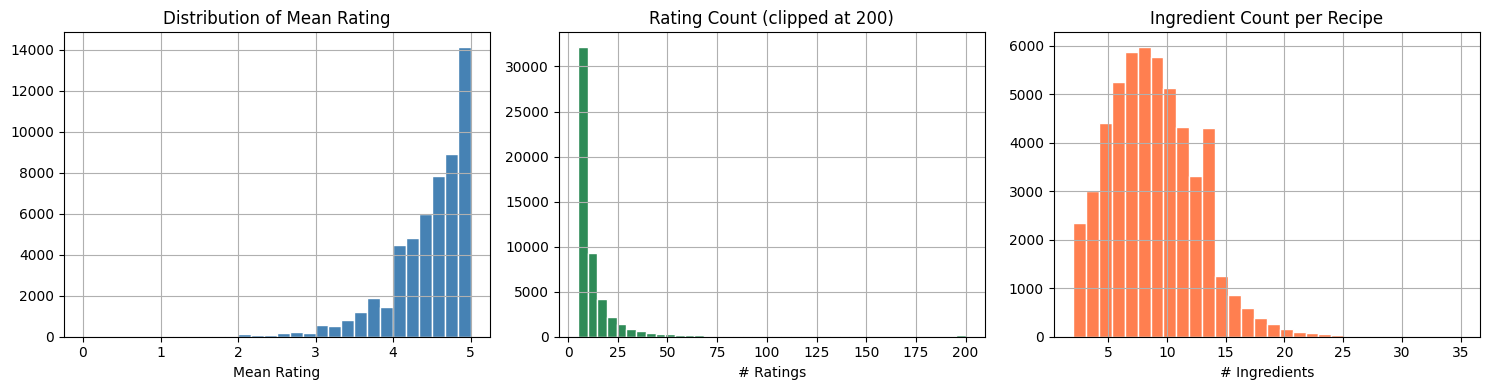

       rating_mean  rating_count  n_ingredients
count     53574.00      53574.00       53574.00
mean          4.45         15.14           8.87
std           0.53         34.48           3.68
min           0.00          5.00           2.00
25%           4.20          6.00           6.00
50%           4.58          8.00           8.00
75%           4.83         14.00          11.00
max           5.00       1613.00          35.00


In [ ]:
# Sanity check: rating distribution after filtering
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["rating_mean"].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Mean Rating")
axes[0].set_xlabel("Mean Rating")

df["rating_count"].clip(upper=200).hist(bins=40, ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("Rating Count (clipped at 200)")
axes[1].set_xlabel("# Ratings")

df["n_ingredients"].hist(bins=30, ax=axes[2], color="coral", edgecolor="white")
axes[2].set_title("Ingredient Count per Recipe")
axes[2].set_xlabel("# Ingredients")

plt.tight_layout()
plt.savefig(OUT_DIR / "01_filter_stats.png", dpi=120)
plt.show()
print(df[["rating_mean", "rating_count", "n_ingredients"]].describe().round(2))

## 3 · Ingredient Name Normalization

Each raw ingredient string like `"2 large free-range eggs"` must be reduced to a canonical token like `"egg"`.  
The cleaning pipeline applies the following steps **in order**:

| Step | What it removes / transforms |
|------|------------------------------|
| Lowercase | `"Fresh Garlic"` → `"fresh garlic"` |
| Strip parenthetical notes | `"tomato (canned)"` → `"tomato"` |
| Remove leading quantities | `"2 1/2 cups"`, `"½ tsp"`, fractions |
| Remove measurement units | `"cup"`, `"tbsp"`, `"oz"`, `"pound"`, … |
| Remove punctuation & extra spaces | |
| spaCy POS filtering | Keep only `NOUN` tokens; drop `ADJ`, `NUM`, `VERB`, … |
| Lemmatization | `"tomatoes"` → `"tomato"`, `"eggs"` → `"egg"` |
| Stop-word & short token removal | Remove generic words (`"can"`, `"fresh"`, tokens < 2 chars) |
| inflect singularization fallback | Catches irregular plurals spaCy may miss |

In [ ]:
# Vulgar fractions and unicode fraction chars
RE_FRACTIONS = re.compile(
    r"\b\d+\s*/\s*\d+\b"
    r"|[\u00BC-\u00BE\u2150-\u215E]" # ¼ ½ ¾ and others
)
RE_QUANTITY = re.compile(r"^\s*[\d.,]+\s*")

# Measurement units — comprehensive culinary list
UNITS = (
    r"cups?|c\.?|tablespoons?|tbsps?|tbs?|teaspoons?|tsps?|ts?"
    r"|ounces?|oz\.?|pounds?|lbs?|lb\.?|grams?|g\.?|kilograms?|kgs?|kg\.?"
    r"|liters?|litres?|ls?|milliliters?|mls?"
    r"|pinch(?:es)?|dash(?:es)?|handfuls?|bunches?|bunch"
    r"|slices?|pieces?|chunks?|strips?|cubes?"
    r"|cans?|jars?|packages?|pkgs?|containers?"
    r"|inches?|in\.?"
)
RE_UNITS = re.compile(
    rf"\b(?:{UNITS})\b\.?",
    re.IGNORECASE
)

# Parenthetical notes: (optional), (about 2 cups), etc.
RE_PARENS = re.compile(r"\(.*?\)")

# Trailing/leading punctuation garbage
RE_PUNCT  = re.compile(r"[^a-z\s]")

CULINARY_STOPWORDS = {
    "fresh", "dried", "frozen", "raw", "cooked", "large", "small", "medium",
    "extra", "fine", "ground", "whole", "half", "ripe", "organic", "free",
    "range", "hot", "cold", "warm", "room", "temperature", "size",
    "use", "cut", "dice", "chop", "mince", "slice", "peel",
    "taste", "serving", "needed", "desired", "optional",
    "can", "jar", "bag", "box", "container", "package"
}

In [ ]:
def normalize_ingredient(raw: str) -> str:
    """
    Transform a raw ingredient string into a canonical noun stem.

    Examples
    --------
    '2 large free-range eggs'          → 'egg'
    '1/2 cup cherry tomatoes, halved'  → 'cherry tomato'
    '3 tbsp. extra-virgin olive oil'   → 'olive oil'
    '½ tsp freshly ground black pepper'→ 'pepper'
    """
    if not isinstance(raw, str):
        return ""

    s = raw.lower().strip()

    # 1 · Remove parenthetical notes
    s = RE_PARENS.sub(" ", s)

    # 2 · Remove fractions, then leading numeric quantities
    s = RE_FRACTIONS.sub(" ", s)
    s = RE_QUANTITY.sub(" ", s)

    # 3 · Remove measurement units
    s = RE_UNITS.sub(" ", s)

    # 4 · Replace hyphens with space (e.g. 'extra-virgin' → 'extra virgin')
    s = s.replace("-", " ")

    # 5 · Strip non-alpha characters (commas, periods, asterisks …)
    s = RE_PUNCT.sub(" ", s)

    # 6 · Collapse whitespace
    s = " ".join(s.split())

    if not s:
        return ""

    # 7 · spaCy: POS-filter (keep NOUN only) + lemmatize
    doc = nlp(s)
    nouns = [
        token.lemma_
        for token in doc
        if token.pos_ in {"NOUN", "PROPN"}          # PROPN catches e.g. 'Parmesan'
        and token.lemma_ not in CULINARY_STOPWORDS
        and len(token.lemma_) >= 2
        and not token.is_stop
    ]

    # 8 · If spaCy returns nothing, fall back to all non-stop words in s
    if not nouns:
        nouns = [
            w for w in s.split()
            if w not in CULINARY_STOPWORDS and len(w) >= 2
        ]

    if not nouns:
        return ""

    # 9 · inflect singularization as an extra safety net
    canonical = []
    for noun in nouns:
        singular = p.singular_noun(noun)
        canonical.append(singular if singular else noun)

    return " ".join(canonical)


test_cases = [
    "2 large free-range eggs",
    "1/2 cup cherry tomatoes, halved",
    "3 tbsp. extra-virgin olive oil",
    "½ tsp freshly ground black pepper",
    "1 (14-oz) can diced tomatoes",
    "salt and pepper to taste",
    "2 cloves garlic, minced",
    "1 medium onion, finely chopped",
    "4 boneless skinless chicken breasts",
    "1 cup all-purpose flour",
]

print(f"{'Raw ingredient':<45} → {'Normalized':<30}")
print("-" * 77)
for t in test_cases:
    print(f"{t:<45} → {normalize_ingredient(t):<30}")

Raw ingredient                                → Normalized                    
-----------------------------------------------------------------------------
2 large free-range eggs                       → egg                           
1/2 cup cherry tomatoes, halved               → cherry tomato                 
3 tbsp. extra-virgin olive oil                → virgin olive oil              
½ tsp freshly ground black pepper             → pepper                        
1 (14-oz) can diced tomatoes                  → tomato                        
salt and pepper to taste                      → salt pepper                   
2 cloves garlic, minced                       → garlic                        
1 medium onion, finely chopped                → onion                         
4 boneless skinless chicken breasts           → boneles skinles chicken breast
1 cup all-purpose flour                       → purpose flour                 


In [ ]:
# Apply normalization to every ingredient in every recipe
def normalize_ingredient_list(ingr_list: list) -> list:
    """Normalize a list of ingredient strings; drop empty results."""
    normalized = [normalize_ingredient(i) for i in ingr_list]
    return [n for n in normalized if n]  # drop empty strings

print("🔄 Normalizing ingredient lists (this may take a few minutes) …")
df["ingredients_clean"] = df["ingredients_list"].progress_apply(normalize_ingredient_list)

# Drop recipes where normalization leaves 0 valid ingredients
before = len(df)
df = df[df["ingredients_clean"].apply(len) >= MIN_INGR]
print(f"\nDropped {before - len(df)} recipes that had <{MIN_INGR} valid ingredients after cleaning")
print(f"✅ Final dataset: {len(df):,} recipes")

🔄 Normalizing ingredient lists (this may take a few minutes) …


  0%|          | 0/53574 [00:00<?, ?it/s]


Dropped 1 recipes that had <2 valid ingredients after cleaning
✅ Final dataset: 53,573 recipes


In [ ]:
# ── Inspect a sample before / after ──────────────────────────────────────────
sample = df.sample(5, random_state=42)[["name", "ingredients_list", "ingredients_clean"]]
for _, row in sample.iterrows():
    print(f"\n📌 {row['name']}")
    print(f"  RAW   : {row['ingredients_list']}")
    print(f"  CLEAN : {row['ingredients_clean']}")


📌 rosy garlic sauteed cabbage
  RAW   : ['canola oil', 'garlic cloves', 'chicken broth', 'green cabbage', 'paprika', 'fresh ground pepper']
  CLEAN : ['canola oil', 'garlic', 'chicken broth', 'green cabbage', 'paprika', 'pepper']

📌 peach and roasted red pepper bruschetta
  RAW   : ['red pepper', 'peaches', 'roma tomatoes', 'garlic clove', 'red wine vinegar', 'fresh basil', 'salt & freshly ground black pepper', 'baguette']
  CLEAN : ['red pepper', 'peach', 'rom tomato', 'clove', 'wine vinegar', 'basil', 'salt pepper', 'baguette']

📌 chicken paprika  csirke paprikash
  RAW   : ['fresh mushrooms', 'onion', 'garlic', 'margarine', 'paprika', 'vinegar', 'all-purpose flour', 'salt', 'celery salt', 'fresh ground pepper', 'boneless skinless chicken breast halves', 'water', 'chicken bouillon granule', 'sour cream', 'medium egg noodles', 'fresh parsley']
  CLEAN : ['mushroom', 'onion', 'garlic', 'margarine', 'paprika', 'vinegar', 'purpose flour', 'salt', 'celery salt', 'pepper', 'boneles skinle

## 4 · Build Ingredient Vocabulary

Construct a vocabulary mapping every unique cleaned ingredient to an integer index.  
This will be used by the LDA-style Bayesian model (Person B/C) as the observed word space.

In [ ]:
# ── Frequency count of all normalized ingredients ────────────────────────────
all_ingr = [ingr for ingr_list in df["ingredients_clean"] for ingr in ingr_list]
ingr_freq = Counter(all_ingr)

print(f"Total ingredient tokens (with repeats): {len(all_ingr):,}")
print(f"Unique normalized ingredients:          {len(ingr_freq):,}")
print(f"\nTop 30 most common ingredients:")
for ingr, count in ingr_freq.most_common(30):
    print(f"  {ingr:<30} {count:>6,}")

Total ingredient tokens (with repeats): 475,034
Unique normalized ingredients:          5,183

Top 30 most common ingredients:
  salt                           24,093
  sugar                          20,550
  onion                          17,434
  butter                         15,811
  pepper                         14,183
  oil                            14,028
  egg                            12,899
  garlic                         11,049
  water                           9,954
  powder                          9,241
  milk                            8,482
  flour                           7,307
  cream                           5,653
  salt pepper                     5,229
  lemon juice                     5,057
  tomato                          4,701
  cinnamon                        4,645
  purpose flour                   4,465
  parsley                         3,995
  parmesan cheese                 3,844
  soda                            3,743
  potato                         

In [ ]:
# ── Frequency-filter: drop ingredients that appear in fewer than MIN_INGR_FREQ recipes
# (very rare tokens are likely OCR errors or mis-normalizations)
MIN_INGR_FREQ = 10

vocab_items = [(ingr, count) for ingr, count in ingr_freq.most_common() if count >= MIN_INGR_FREQ]
print(f"Vocabulary size after min_freq≥{MIN_INGR_FREQ}: {len(vocab_items):,} ingredients")

# Build index maps
vocab_list = [ingr for ingr, _ in vocab_items]
ingr2idx   = {ingr: idx for idx, ingr in enumerate(vocab_list)}
idx2ingr   = {idx: ingr for ingr, idx in ingr2idx.items()}

# Filter ingredient lists to vocabulary (drop OOV tokens)
df["ingredients_vocab"] = df["ingredients_clean"].apply(
    lambda lst: [i for i in lst if i in ingr2idx]
)

# Final drop: recipes whose ingredients are entirely OOV
before = len(df)
df = df[df["ingredients_vocab"].apply(len) >= MIN_INGR]
print(f"Dropped {before - len(df)} recipes with all OOV ingredients → {len(df):,} remain")

Vocabulary size after min_freq≥10: 1,617 ingredients
Dropped 142 recipes with all OOV ingredients → 53,431 remain


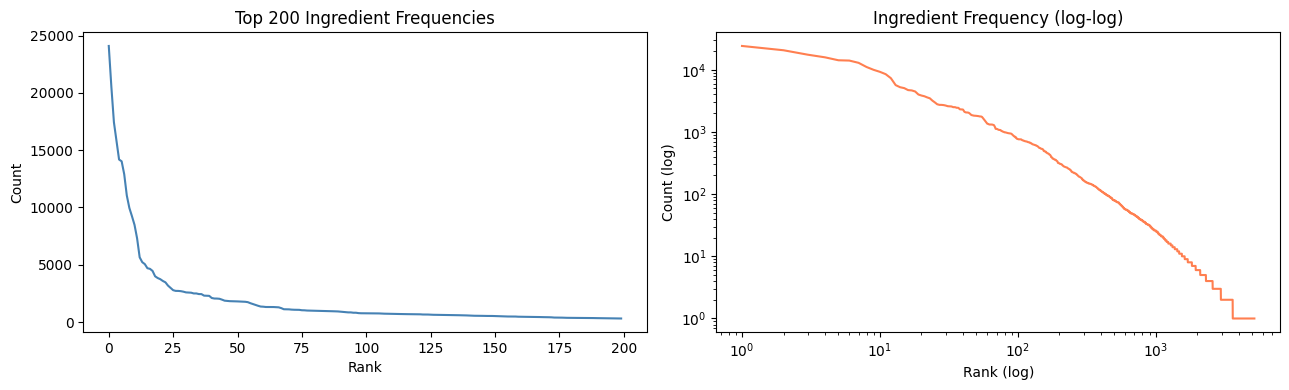

In [ ]:
# ── Visualize vocabulary frequency distribution (Zipf's law) ─────────────────
freqs = sorted([count for _, count in ingr_freq.items()], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(freqs[:200], color="steelblue")
axes[0].set_title("Top 200 Ingredient Frequencies")
axes[0].set_xlabel("Rank"); axes[0].set_ylabel("Count")

axes[1].loglog(range(1, len(freqs)+1), freqs, color="coral")
axes[1].set_title("Ingredient Frequency (log-log)")
axes[1].set_xlabel("Rank (log)"); axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.savefig(OUT_DIR / "02_vocab_frequency.png", dpi=120)
plt.show()

## 5 · Output Standardized Files

Three files are produced for downstream tasks:

| File | Description |
|------|-------------|
| `recipes_clean.csv` | Filtered and normalized recipe table |
| `ingredient_vocab.json` | `{ingredient_string: index}` mapping |
| `ingredient_freq.csv` | Ingredient frequency table (for EDA) |

In [ ]:
# ── Select and rename columns for the clean recipe CSV ───────────────────────
COLS_OUT = [
    "id", "name",
    "minutes",
    "submitted",
    "n_steps",
    "steps",
    "description",
    "n_ingredients",
    "ingredients_list",    # original parsed list
    "ingredients_clean",   # after spaCy normalization
    "ingredients_vocab",   # after vocab filtering
    "nutrition",
    "tags",
    "rating_count",
    "rating_mean",
]

df_out = df[COLS_OUT].copy()

# Serialize list columns as JSON strings (safe, parseable downstream)
for col in ["ingredients_list", "ingredients_clean", "ingredients_vocab"]:
    df_out[col] = df_out[col].apply(json.dumps)

# ── Save recipe CSV ───────────────────────────────────────────────────────────
recipe_csv_path = OUT_DIR / "recipes_clean.csv"
df_out.to_csv(recipe_csv_path, index=False)
print(f"✅ recipes_clean.csv saved  → {recipe_csv_path}  ({len(df_out):,} rows)")

# ── Save ingredient vocabulary ────────────────────────────────────────────────
vocab_dict = {
    "ingr2idx": ingr2idx,
    "idx2ingr": idx2ingr,
    "vocab_size": len(ingr2idx),
    "min_freq_threshold": MIN_INGR_FREQ,
}
vocab_path = OUT_DIR / "ingredient_vocab.json"
with open(vocab_path, "w") as f:
    json.dump(vocab_dict, f, indent=2)
print(f"✅ ingredient_vocab.json saved → {vocab_path}  ({len(ingr2idx):,} entries)")

# ── Save frequency table ──────────────────────────────────────────────────────
freq_df = pd.DataFrame(ingr_freq.most_common(), columns=["ingredient", "count"])
freq_df["in_vocab"] = freq_df["ingredient"].isin(ingr2idx)
freq_path = OUT_DIR / "ingredient_freq.csv"
freq_df.to_csv(freq_path, index=False)
print(f"✅ ingredient_freq.csv saved  → {freq_path}  ({len(freq_df):,} unique ingredients)")

✅ recipes_clean.csv saved  → output/recipes_clean.csv  (53,431 rows)
✅ ingredient_vocab.json saved → output/ingredient_vocab.json  (1,617 entries)
✅ ingredient_freq.csv saved  → output/ingredient_freq.csv  (5,183 unique ingredients)


## 6 · Summary Report & Handoff Notes

In [ ]:
print("="*60)
print("DATA ENGINEERING SUMMARY")
print("="*60)
print(f"Input recipes (raw)       : {initial_count:>8,}")
print(f"Output recipes (clean)    : {len(df):>8,}")
print(f"Retention rate            : {100*len(df)/initial_count:>7.1f}%")
print()
print(f"Vocabulary size           : {len(ingr2idx):>8,} ingredients")
print(f"Min-freq threshold        : {MIN_INGR_FREQ:>8,} occurrences")
print()
print("Output files:")
print(f"  recipes_clean.csv       → {len(df):,} rows × {len(COLS_OUT)} cols")
print(f"  ingredient_vocab.json   → {len(ingr2idx):,} canonical ingredients")
print(f"  ingredient_freq.csv     → {len(freq_df):,} unique tokens with counts")
print()
print("Rating statistics:")
print(df[["rating_count", "rating_mean"]].describe().round(2).to_string())
print()
print("Ingredient count statistics:")
print(df["n_ingredients"].describe().round(2).to_string())
print("="*60)

DATA ENGINEERING SUMMARY
Input recipes (raw)       :  231,637
Output recipes (clean)    :   53,431
Retention rate            :    23.1%

Vocabulary size           :    1,617 ingredients
Min-freq threshold        :       10 occurrences

Output files:
  recipes_clean.csv       → 53,431 rows × 15 cols
  ingredient_vocab.json   → 1,617 canonical ingredients
  ingredient_freq.csv     → 5,183 unique tokens with counts

Rating statistics:
       rating_count  rating_mean
count      53431.00     53431.00
mean          15.15         4.45
std           34.52         0.53
min            5.00         0.00
25%            6.00         4.20
50%            8.00         4.58
75%           14.00         4.83
max         1613.00         5.00

Ingredient count statistics:
count    53431.00
mean         8.88
std          3.66
min          2.00
25%          6.00
50%          8.00
75%         11.00
max         35.00


## 7 · EDA


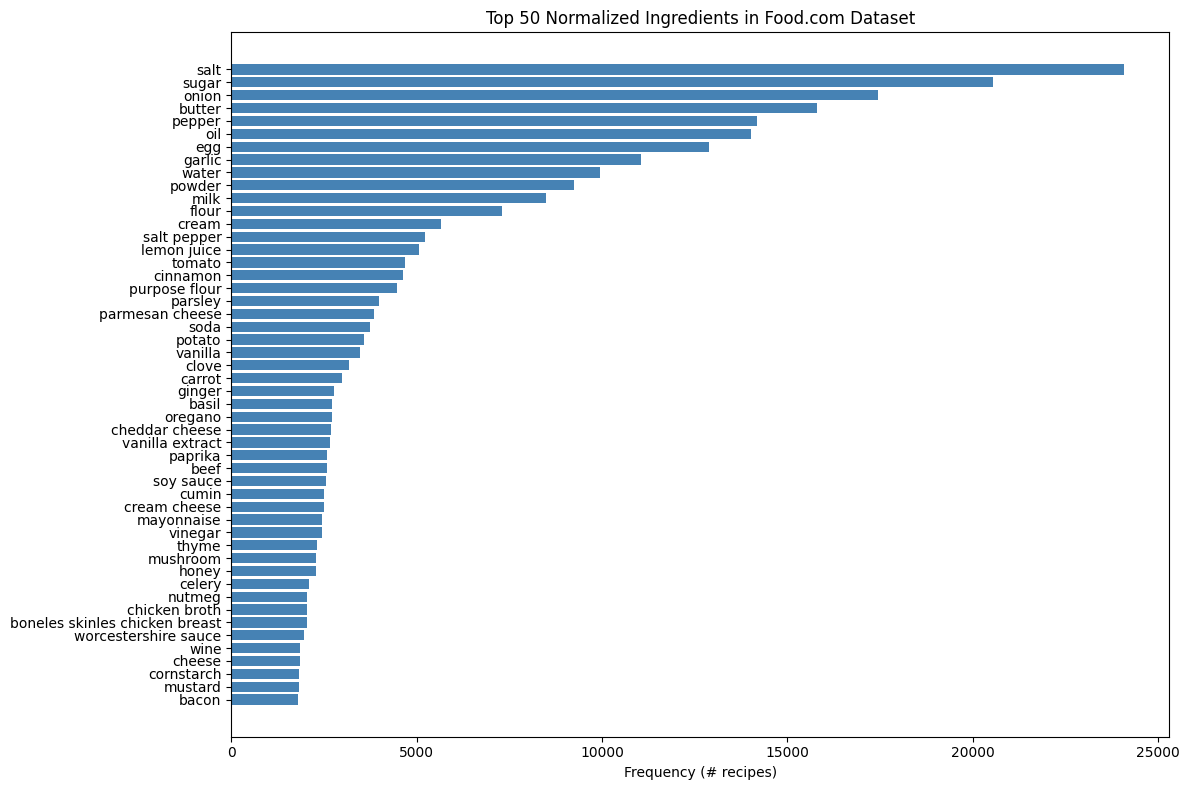

In [ ]:
# ── Top-50 ingredient bar chart ───────────────────────────────────────────────
top50 = freq_df[freq_df["in_vocab"]].head(50)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top50["ingredient"][::-1], top50["count"][::-1], color="steelblue")
ax.set_xlabel("Frequency (# recipes)")
ax.set_title("Top 50 Normalized Ingredients in Food.com Dataset")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_top50_ingredients.png", dpi=120)
plt.show()

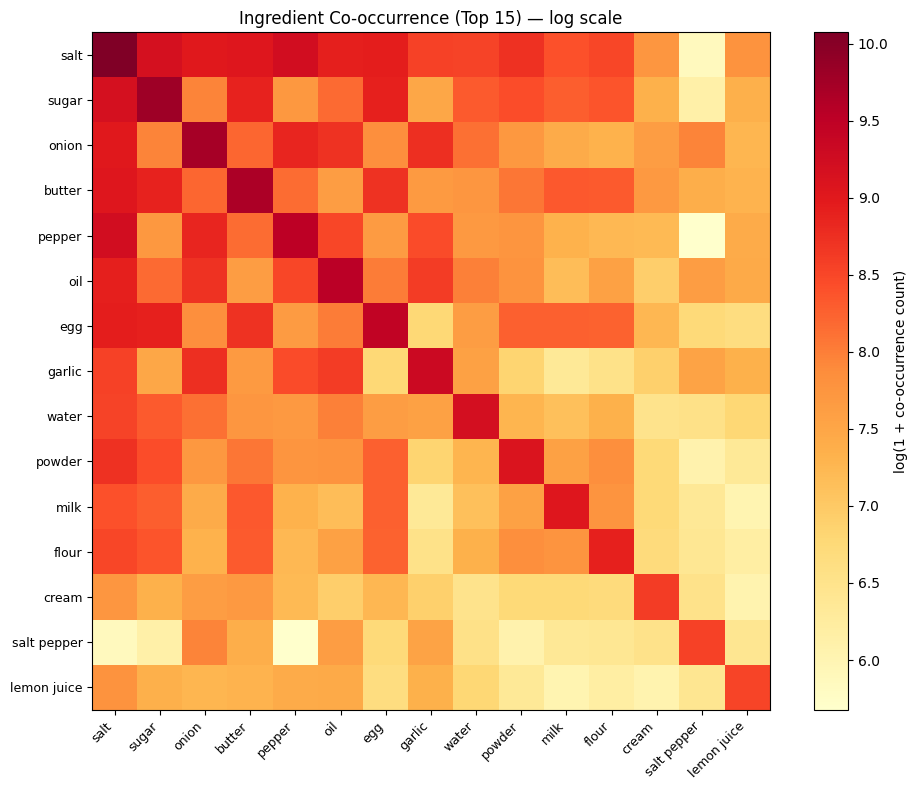

In [ ]:
# ── Ingredient co-occurrence heatmap (top 15 ingredients) ────────────────────
TOP_N  = 15
top_ingrs = [ingr for ingr, _ in ingr_freq.most_common(TOP_N)]
comat = np.zeros((TOP_N, TOP_N), dtype=int)

for ingr_list in df["ingredients_clean"]:
    present = set(ingr_list) & set(top_ingrs)
    for a in present:
        for b in present:
            i, j = top_ingrs.index(a), top_ingrs.index(b)
            comat[i, j] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(np.log1p(comat), cmap="YlOrRd")
ax.set_xticks(range(TOP_N)); ax.set_yticks(range(TOP_N))
ax.set_xticklabels(top_ingrs, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(top_ingrs, fontsize=9)
plt.colorbar(im, ax=ax, label="log(1 + co-occurrence count)")
ax.set_title(f"Ingredient Co-occurrence (Top {TOP_N}) — log scale")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_cooccurrence_heatmap.png", dpi=120)
plt.show()

In [ ]:
print("🎉 Data Engineering pipeline complete!")
print(f"All outputs saved to: {OUT_DIR.resolve()}")
import os
for fp in sorted(OUT_DIR.iterdir()):
    size_kb = fp.stat().st_size / 1024
    print(f"  {fp.name:<35} {size_kb:>8.1f} KB")

🎉 Data Engineering pipeline complete!
All outputs saved to: /content/output
  01_filter_stats.png                     55.2 KB
  02_vocab_frequency.png                  51.7 KB
  03_top50_ingredients.png                96.6 KB
  04_cooccurrence_heatmap.png             69.0 KB
  ingredient_freq.csv                    118.7 KB
  ingredient_vocab.json                   84.4 KB
  recipes_clean.csv                    81603.7 KB
